In [5]:
import numpy as np
import pandas as pd

In [6]:
data_1 = pd.read_excel('CompleteDataWithDemographics_Cleaned.xlsx')
data_1.head()

,Category,Finished,How old are you?,How do you describe yourself? - Selected Choice,How do you describe yourself? - Prefer to self-describe - Text,What is your major?,What year of college are you in? - Year,"Generally speaking, do you usually think of yourself as a Republican, a Democrat, an Independent, or something else? - Selected Choice","Generally speaking, do you usually think of yourself as a Republican, a Democrat, an Independent, or something else? - Other - Text",If you answered Independent are you more left leaning or right leaning?,...,Cell Phone - Which of the following statements best captures your views on the Law banning use of\ncell phones by children in schools?,Cell Phone - Should all 50 states and jurisdictions enact and implement the Law that bans the use of cell_x000D_\nphones by children in Schools?,Cell Phone - What do you agree with? What do you disagree with?,Cell Phone - From which of the following information sources did you hear about the Law banning use\nof cell phones by children in schools?,"Cell Phone - After reading both summaries, which do you find more credible?","Cell Phone - If you don't feel either summary is credible, please expand on why.",Cell Phone - Which summary did you find more engaging? What about the summary made it more enjoyable to you?,"Cell Phone - Which of the summaries had better quality? (writing style, clarity, coherency, comprehensiveness)\n\nPlease be specific",Cell Phone - Which summary did you feel was more representative of the topic and all parties involved?\n\nPlease be specific,Path
0,Credit,True,18-24 years old,Female,NaN,Human Resource Management,Sophmore,Republican,NaN,NaN,...,It is a good Law but implementation should be ...,Partially agree,I think it is every states right to decide if ...,NaN,Don't Confuse Control With Care: The Tyrannica...,NaN,The original summary (more detail),The original summary,The original summary,A(1->4)
1,Credit,True,18-24 years old,Female,NaN,International Business,Junior,No preference,NaN,NaN,...,It is unconstitutional because it violates the...,Do not agree,NaN,Social Media,The State of Play: Unpacking the Nationwide De...,NaN,"For me, the second summary was a better read. ...",The second summary had by far better quality b...,Both summary's get both the students and paren...,A(1->4)
2,Credit,True,18-24 years old,Male,NaN,Business Admin,Freshman,Democrat,NaN,NaN,...,It is constitutional and does not violate the ...,Do not agree,NaN,NaN,Don't Confuse Control With Care: The Tyrannica...,NaN,More engaging,Both had good quality,Both,A(1->4)
3,Credit,True,18-24 years old,Male,NaN,Finance,Freshman,No preference,NaN,NaN,...,It is constitutional and does not violate the ...,Agree,NaN,"Social Media,News Apps,National Print Newspaper",The State of Play: Unpacking the Nationwide De...,NaN,second one was less confusing,second one,second one,A(1->4)
4,Credit,True,18-24 years old,Female,NaN,Molecular Biology,Freshman,No preference,NaN,NaN,...,It is unconstitutional because it violates the...,Do not agree,NaN,"Social Media,News Apps",The State of Play: Unpacking the Nationwide De...,NaN,Don't confused control with care was a bit mor...,"The state of play had better quality, it was e...","Don't confuse control with care, it was more i...",A(1->4)


In [10]:
data_df = pd.DataFrame()
data_df['student_responses'] = data_1['SAVE ACT - Now that you have learned about the Save Act summarize the key arguments from the proponents and opponents of the topic.']

In [13]:
data_df.to_csv('student_responses.csv')

In [51]:
data_2 = pd.read_csv('output.csv')
data_2.head()

,response_id,question_prompt,student_response,accurate_score,credible_score,believable_score,objective_score,necessary_score,legitimate_score,discriminatory_score,overall_civic_literacy_score,brief_rationale
0,1,SAVE ACT - Now that you have learned about the...,Proponents: \nEnsuring only citizens vote \nac...,5,5,5,5,5,5,0,5,"Comprehensive, balanced summary of both propon..."
1,2,SAVE ACT - Now that you have learned about the...,The SAVE Act requires all voter registration a...,4,4,4,3,3,4,0,4,Accurate description of proof-of-citizenship r...
2,3,SAVE ACT - Now that you have learned about the...,A bill that would require all Americans to pro...,4,3,4,4,2,3,0,3,"Accurate bill description, but it does not sum..."
3,4,SAVE ACT - Now that you have learned about the...,"Proponents want voters to have id, opponents d...",2,2,3,2,1,2,0,2,Overly simplified and mischaracterizes opponen...
4,5,SAVE ACT - Now that you have learned about the...,Trump wrote the safe act in order to stop immi...,1,1,2,1,2,1,0,1,Contains unsupported and likely inaccurate cla...


In [57]:
import re

def clean_text(x):
    if pd.isna(x):
        return ""
    
    x = str(x)
    x = x.replace("\u00a0", " ")  # non-breaking space
    x = x.replace("“", '"').replace("”", '"')
    x = x.replace("’", "'")
    x = x.lower()
    x = re.sub(r"\s+", " ", x)    # все переносы строк и лишние пробелы → один пробел
    x = x.strip()
    
    return x


data_1["student_response"] = data_1['student_response'].apply(clean_text)
data_2["student_response"] = data_2['student_response'].apply(clean_text)

merged = data_1.merge(
    data_2,
    on="student_response",
    how="left"
)

np.int64(0)

In [59]:
sample_1 = merged[(merged['Path'] == 'A(1->4)') | (merged['Path'] == 'D(4->1)')]
sample_2 = merged[(merged['Path'] == 'B(2->3)') | (merged['Path'] == 'C(3->2)')]

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, mannwhitneyu

metrics = [
    "accurate_score",
    "credible_score",
    "believable_score",
    "objective_score",
    "necessary_score",
    "legitimate_score",
    "discriminatory_score",
    "overall_civic_literacy_score"
]

# Создаем общий dataframe с группой
s1 = sample_1.copy()
s2 = sample_2.copy()

s1["sample_group"] = "Sample 1: A(1->4) + D(4->1)"
s2["sample_group"] = "Sample 2: B(2->3) + C(3->2)"

df_compare = pd.concat([s1, s2], ignore_index=True)

# Scores должны быть numeric
for col in metrics:
    df_compare[col] = pd.to_numeric(df_compare[col], errors="coerce")

# Убираем строки без overall score
df_compare = df_compare.dropna(subset=["overall_civic_literacy_score"])

df_compare["sample_group"].value_counts()

sample_group
Sample 2: B(2->3) + C(3->2)    44
Sample 1: A(1->4) + D(4->1)    42
Name: count, dtype: int64

In [75]:
means = df_compare.groupby("sample_group")[metrics].mean().round(3)
means

,accurate_score,credible_score,believable_score,objective_score,necessary_score,legitimate_score,discriminatory_score,overall_civic_literacy_score
sample_group,,,,,,,,
Sample 1: A(1->4) + D(4->1),3.286,2.929,3.833,3.762,2.881,3.214,0.262,3.00
Sample 2: B(2->3) + C(3->2),3.159,2.795,3.841,3.568,2.409,2.909,0.136,2.75


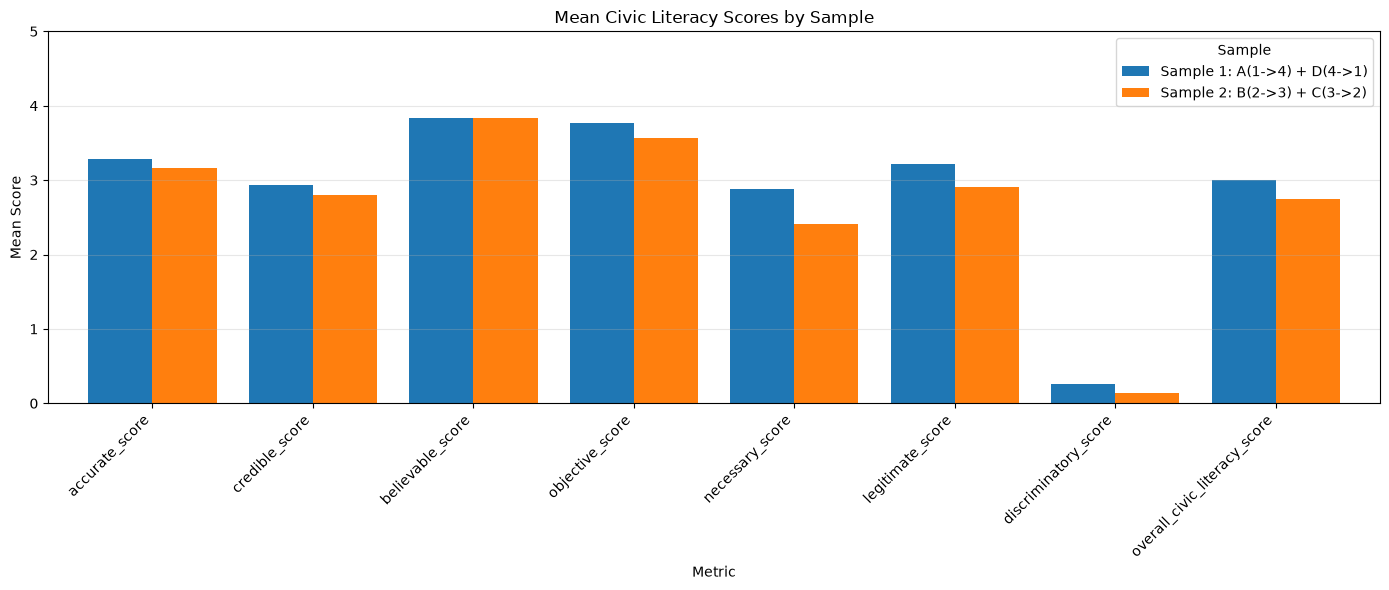

In [76]:
means_plot = df_compare.groupby("sample_group")[metrics].mean().T

ax = means_plot.plot(
    kind="bar",
    figsize=(14, 6),
    width=0.8
)

plt.title("Mean Civic Literacy Scores by Sample")
plt.ylabel("Mean Score")
plt.xlabel("Metric")
plt.ylim(0, 5)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sample")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: xlabel='overall_civic_literacy_score', ylabel='Count'>

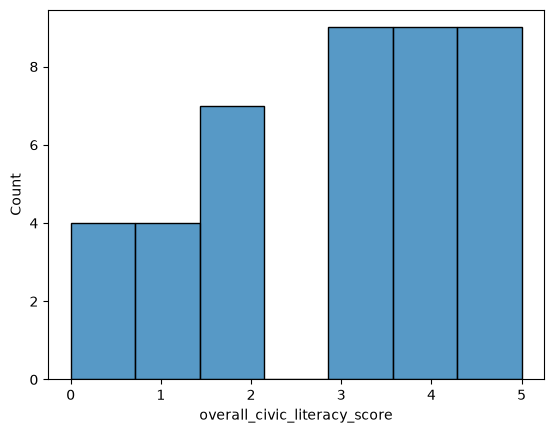

In [85]:
sns.histplot(data=sample_1, x="overall_civic_literacy_score")

<Axes: xlabel='overall_civic_literacy_score', ylabel='Count'>

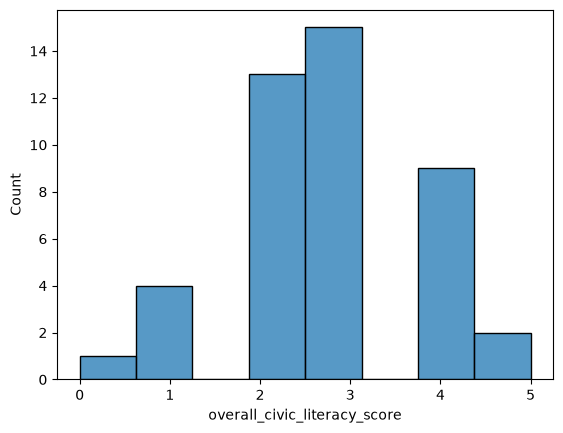

In [86]:
sns.histplot(data=sample_2, x="overall_civic_literacy_score")

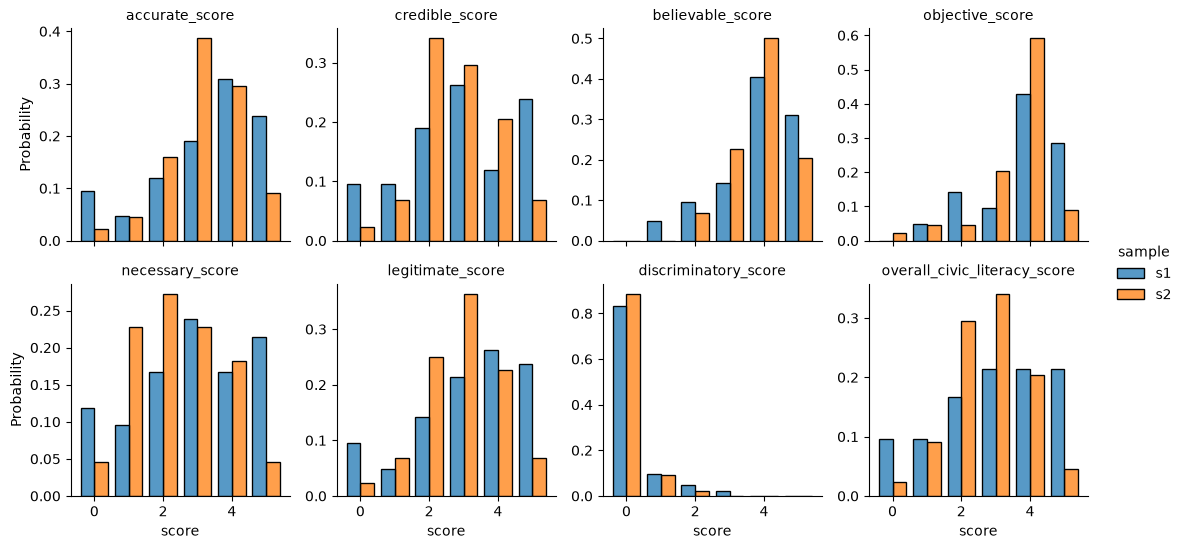

In [87]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metrics = [
    "accurate_score", "credible_score", "believable_score", "objective_score",
    "necessary_score", "legitimate_score", "discriminatory_score",
    "overall_civic_literacy_score",
]

# помечаем и склеиваем
combined = pd.concat([
    sample_1[metrics].assign(sample="s1"),
    sample_2[metrics].assign(sample="s2"),
], ignore_index=True)

long = combined.melt(id_vars="sample", var_name="metric", value_name="score")

g = sns.displot(
    data=long, x="score", hue="sample",
    col="metric", col_wrap=4,
    stat="probability",    
    common_norm=False,      
    multiple="dodge",      
    discrete=True, shrink=0.8,
    height=2.8, facet_kws={"sharey": False},
)
g.set_titles("{col_name}")
plt.show()

In [91]:
from scipy.stats import mannwhitneyu

for m in metrics:
    x = sample_1[m].dropna()
    y = sample_2[m].dropna()
    p = mannwhitneyu(x, y, alternative="two-sided").pvalue
    print(f"{m:35s} p = {p:.4f}")

accurate_score                      p = 0.2952
credible_score                      p = 0.5498
believable_score                    p = 0.6392
objective_score                     p = 0.2193
necessary_score                     p = 0.1184
legitimate_score                    p = 0.1375
discriminatory_score                p = 0.4467
overall_civic_literacy_score        p = 0.2726


In [92]:
from scipy.stats import chi2_contingency
import pandas as pd

for m in metrics:
    # таблица: строки = балл, столбцы = выборка
    tab = pd.concat([
        sample_1[m].value_counts().rename("s1"),
        sample_2[m].value_counts().rename("s2"),
    ], axis=1).fillna(0)
    p = chi2_contingency(tab)[1]
    print(f"{m:35s} p = {p:.4f}")

accurate_score                      p = 0.1617
credible_score                      p = 0.1047
believable_score                    p = 0.3465
objective_score                     p = 0.0662
necessary_score                     p = 0.0857
legitimate_score                    p = 0.1011
discriminatory_score                p = 0.6814
overall_civic_literacy_score        p = 0.0903


In [ ]:
['objective_score']